In [3]:
!pip install opencv-python
!pip install openpyxl


  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)


In [4]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np

# Leer el archivo Excel
e1 = pd.read_excel('datos_procesados_empresa1_con_imagen.xlsx')


# Mostrar las primeras filas del DataFrame
e1.head()

,ORIG_STD_VOLUME,STD_VOLUME,ORIG_TEMPERATURE,TEMPERATURE,PRESSURE,ORIG_PRESSURE,ORIG_RAW_VOLUME,RAW_VOLUME,EFFECTIVE_DATE,image_filename
0,-2.029433,-2.027449,-1.006428,-1.006428,0.336045,0.336045,-2.164089,-2.161837,2018-09-03 09:00:00,Año2018_Día2018-09-03.png
1,-1.929310,-1.927454,-0.951826,-0.951826,0.369934,0.369934,0.647292,0.645791,2018-09-03 10:00:00,Año2018_Día2018-09-03.png
2,-1.920680,-1.918836,-0.885619,-0.885619,0.342728,0.342728,0.891760,0.889933,2018-09-03 11:00:00,Año2018_Día2018-09-03.png
3,-1.944717,-1.942842,-0.881222,-0.881222,0.375454,0.375454,0.212682,0.211762,2018-09-03 12:00:00,Año2018_Día2018-09-03.png
4,-1.948351,-1.946471,-0.881142,-0.881142,0.347026,0.347026,0.117611,0.116818,2018-09-03 13:00:00,Año2018_Día2018-09-03.png


In [5]:
# SCalcular el percentil 99 global para evitar que las anomalías dominen
global_max = np.percentile(e1["ORIG_RAW_VOLUME"], 99)
 
# Aplicar normalización dividiendo por ese valor máximo
e1["ORIG_RAW_VOLUME_NORM"] = e1["ORIG_RAW_VOLUME"] / global_max
e1["ORIG_RAW_VOLUME_NORM"] = np.clip(e1["ORIG_RAW_VOLUME_NORM"], 0, 1)

Skipping group with insufficient data: Año2019_Día2019-01-13.png
Epoch 1/20
49/49 [==============================] - 40s 678ms/step - loss: 0.5289 - accuracy: 0.7430 - val_loss: 0.5004 - val_accuracy: 0.7647
Epoch 2/20
49/49 [==============================] - 30s 624ms/step - loss: 0.4421 - accuracy: 0.7845 - val_loss: 0.4926 - val_accuracy: 0.7468
Epoch 3/20
49/49 [==============================] - 31s 640ms/step - loss: 0.4137 - accuracy: 0.8012 - val_loss: 0.4655 - val_accuracy: 0.7724
Epoch 4/20
49/49 [==============================] - 33s 684ms/step - loss: 0.4049 - accuracy: 0.8037 - val_loss: 0.4643 - val_accuracy: 0.7545
Epoch 5/20
49/49 [==============================] - 31s 629ms/step - loss: 0.4036 - accuracy: 0.8152 - val_loss: 0.5565 - val_accuracy: 0.7366
Epoch 6/20
49/49 [==============================] - 31s 625ms/step - loss: 0.3836 - accuracy: 0.8210 - val_loss: 0.4972 - val_accuracy: 0.7366
Epoch 7/20
49/49 [==============================] - 32s 655ms/step - loss: 0.

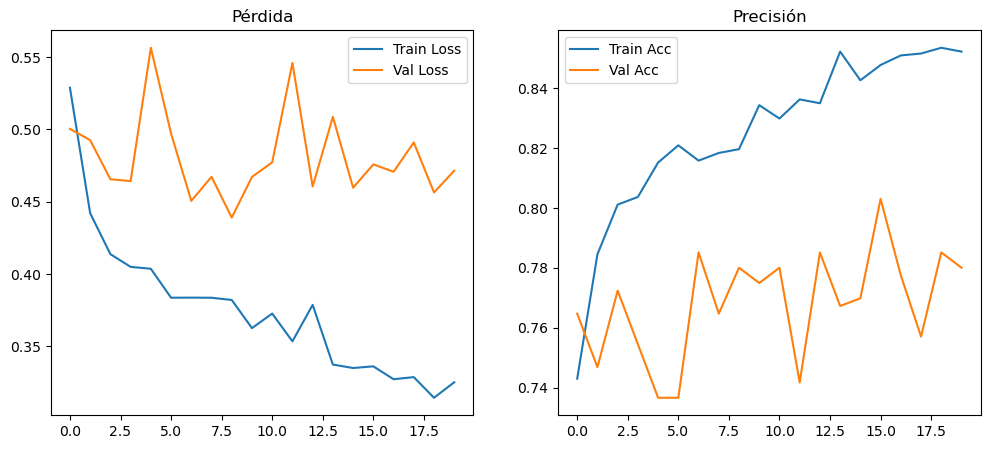

49/49 [==============================] - 40s 726ms/step

📊 Resultados para Train
Matriz de Confusión:
[[616 172]
 [ 58 718]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.91      0.78      0.84       788
           1       0.81      0.93      0.86       776

    accuracy                           0.85      1564
   macro avg       0.86      0.85      0.85      1564
weighted avg       0.86      0.85      0.85      1564



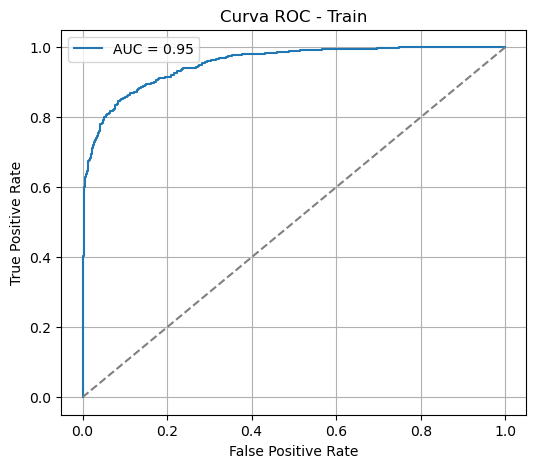

13/13 [==============================] - 10s 730ms/step

📊 Resultados para Test
Matriz de Confusión:
[[140  58]
 [ 28 165]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.83      0.71      0.77       198
           1       0.74      0.85      0.79       193

    accuracy                           0.78       391
   macro avg       0.79      0.78      0.78       391
weighted avg       0.79      0.78      0.78       391



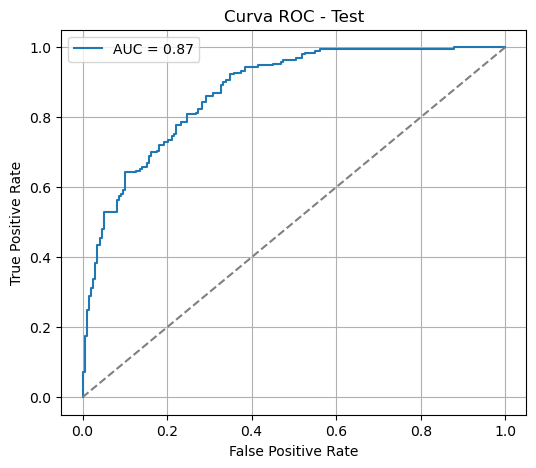

In [11]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, GlobalAveragePooling2D, Concatenate, Dropout
from tensorflow.keras.applications import MobileNetV2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc


# ==== CARGA DE DATOS ====
# Asegúrate de tener e1 ya cargado:
# e1 = pd.read_excel("datos_procesados_empresa1_con_imagen.xlsx")

# ==== CONFIGURACIÓN ====
img_base_dir = r"C:\Users\jupap\OneDrive - Universidad de los andes\Tesis Camiii\ProyectoGradoGEB\imagenes_diarias"  # 📌 Reemplaza con la ruta real
  # contiene las carpetas "normal" y "anomalo"
img_size = (224, 224)
batch_size = 32
epochs = 20

# ==== VARIABLES DE TIEMPO A USAR ====
features = ["STD_VOLUME", "ORIG_STD_VOLUME", "ORIG_TEMPERATURE", "TEMPERATURE",
            "PRESSURE", "ORIG_PRESSURE", "RAW_VOLUME", "ORIG_RAW_VOLUME"]
scaler = StandardScaler()
e1[features] = scaler.fit_transform(e1[features])

# ==== AGRUPACIÓN POR DÍA ====
X_img, X_seq, y = [], [], []

for name, group in e1.groupby("image_filename"):
    # Verificar si la imagen está en alguna carpeta
    img_path_normal = os.path.join(img_base_dir, "normal", name)
    img_path_anomalo = os.path.join(img_base_dir, "anomalo", name)

    if os.path.exists(img_path_anomalo):
        img_path = img_path_anomalo
        label = 1
    elif os.path.exists(img_path_normal):
        img_path = img_path_normal
        label = 0
    else:
        print(f"Image not found: {name}")
        continue  # imagen no encontrada
    
    with open(img_path, 'rb') as f:
        file_bytes = np.asarray(bytearray(f.read()), dtype=np.uint8)
        img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

    if img is None: 
        print(f"Failed to load image: {img_path}")
        continue  # imagen dañada
    img = cv2.resize(img, img_size)
    img = img / 255.0

    # Datos de series de tiempo del día
    seq = group[features].values
    if seq.shape[0] < 6: 
        print(f"Skipping group with insufficient data: {name}")
        continue  # evitar días con muy pocas horas
    X_img.append(img)
    X_seq.append(seq)
    y.append(label)

# Check if data was loaded successfully
if len(X_img) == 0 or len(X_seq) == 0 or len(y) == 0:
    raise ValueError("No data was loaded. Please check the image paths and data preprocessing steps.")

# ==== CONVERTIR A NUMPY ====
X_img = np.array(X_img)
X_seq = tf.keras.preprocessing.sequence.pad_sequences(X_seq, padding="post", dtype="float32")
y = np.array(y)

# ==== DIVISIÓN ====
X_train_img, X_test_img, X_train_seq, X_test_seq, y_train, y_test = train_test_split(
    X_img, X_seq, y, test_size=0.2, random_state=42
)

# ==== MODELO CNN + LSTM ====
img_input = Input(shape=(224, 224, 3))
cnn_base = MobileNetV2(include_top=False, weights="imagenet", input_tensor=img_input)
cnn_base.trainable = False
cnn_output = GlobalAveragePooling2D()(cnn_base.output)

seq_input = Input(shape=(X_seq.shape[1], X_seq.shape[2]))
lstm_output = LSTM(64)(seq_input)

fusion = Concatenate()([cnn_output, lstm_output])
x = Dense(128, activation="relu")(fusion)
x = Dropout(0.3)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=[img_input, seq_input], outputs=output)
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# ==== ENTRENAMIENTO ====
history = model.fit(
    [X_train_img, X_train_seq], y_train,
    validation_data=([X_test_img, X_test_seq], y_test),
    epochs=epochs,
    batch_size=batch_size
)

# ==== GRÁFICAS DE PÉRDIDA Y PRECISIÓN ====
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Pérdida")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("Precisión")
plt.legend()
plt.show()

# === MÉTRICAS EN TRAIN Y TEST ===
for name, X_img_set, X_seq_set, y_true in zip(
    ["Train", "Test"],
    [X_train_img, X_test_img],
    [X_train_seq, X_test_seq],
    [y_train, y_test]
):
    y_pred_proba = model.predict([X_img_set, X_seq_set])
    y_pred = (y_pred_proba > 0.5).astype(int)

    print(f"\n📊 Resultados para {name}")
    print("Matriz de Confusión:")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    print("\nReporte de Clasificación:")
    print(classification_report(y_true, y_pred))

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.title(f"Curva ROC - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid()
    plt.show()


# ==== GUARDAR MODELO ====
model.save("modelo_cnn_lstm.h5")



=== Fold 1/5 ===
Epoch 1/20
49/49 [==============================] - 34s 588ms/step - loss: 0.5388 - accuracy: 0.7283
Epoch 2/20
49/49 [==============================] - 29s 588ms/step - loss: 0.4486 - accuracy: 0.7832
Epoch 3/20
49/49 [==============================] - 32s 646ms/step - loss: 0.4458 - accuracy: 0.7928
Epoch 4/20
49/49 [==============================] - 31s 622ms/step - loss: 0.4157 - accuracy: 0.7948
Epoch 5/20
49/49 [==============================] - 28s 578ms/step - loss: 0.4044 - accuracy: 0.8159
Epoch 6/20
49/49 [==============================] - 29s 591ms/step - loss: 0.3943 - accuracy: 0.8159
Epoch 7/20
49/49 [==============================] - 28s 571ms/step - loss: 0.3747 - accuracy: 0.8197
Epoch 8/20
49/49 [==============================] - 28s 572ms/step - loss: 0.3658 - accuracy: 0.8235
Epoch 9/20
49/49 [==============================] - 28s 571ms/step - loss: 0.3784 - accuracy: 0.8216
Epoch 10/20
49/49 [==============================] - 28s 572ms/step - los

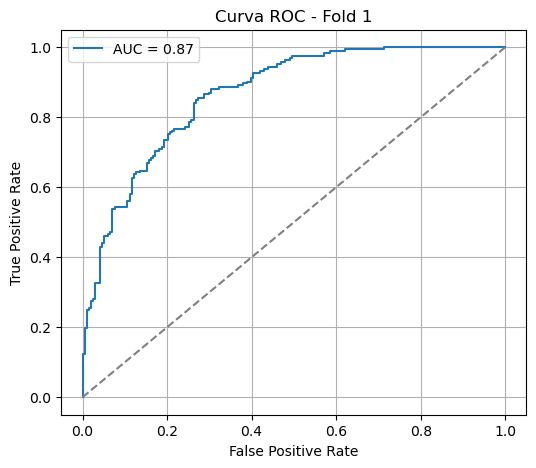


=== Fold 2/5 ===
Epoch 1/20
49/49 [==============================] - 36s 630ms/step - loss: 0.6288 - accuracy: 0.6426
Epoch 2/20
49/49 [==============================] - 30s 608ms/step - loss: 0.4701 - accuracy: 0.7653
Epoch 3/20
49/49 [==============================] - 28s 575ms/step - loss: 0.4291 - accuracy: 0.7909
Epoch 4/20
49/49 [==============================] - 27s 558ms/step - loss: 0.4250 - accuracy: 0.7813
Epoch 5/20
49/49 [==============================] - 29s 586ms/step - loss: 0.4196 - accuracy: 0.8005
Epoch 6/20
49/49 [==============================] - 28s 573ms/step - loss: 0.4099 - accuracy: 0.7954
Epoch 7/20
49/49 [==============================] - 29s 585ms/step - loss: 0.4022 - accuracy: 0.8114
Epoch 8/20
49/49 [==============================] - 30s 615ms/step - loss: 0.3991 - accuracy: 0.8050
Epoch 9/20
49/49 [==============================] - 29s 600ms/step - loss: 0.3852 - accuracy: 0.8229
Epoch 10/20
49/49 [==============================] - 27s 560ms/step - los

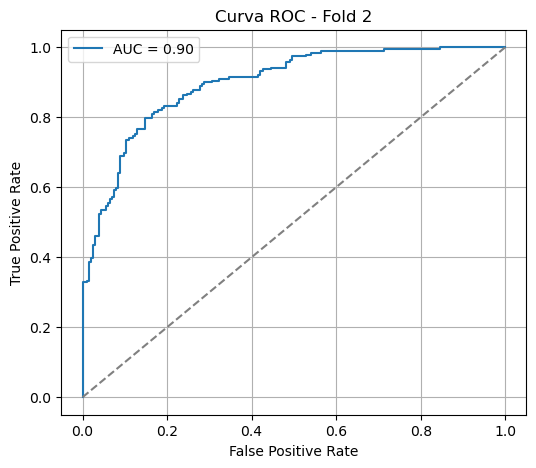


=== Fold 3/5 ===
Epoch 1/20
49/49 [==============================] - 36s 632ms/step - loss: 0.5495 - accuracy: 0.7097
Epoch 2/20
49/49 [==============================] - 27s 560ms/step - loss: 0.4445 - accuracy: 0.7820
Epoch 3/20
49/49 [==============================] - 28s 567ms/step - loss: 0.4328 - accuracy: 0.7877
Epoch 4/20
49/49 [==============================] - 28s 577ms/step - loss: 0.4150 - accuracy: 0.8031
Epoch 5/20
49/49 [==============================] - 29s 583ms/step - loss: 0.3960 - accuracy: 0.8075
Epoch 6/20
49/49 [==============================] - 26s 536ms/step - loss: 0.4005 - accuracy: 0.8095
Epoch 7/20
49/49 [==============================] - 29s 602ms/step - loss: 0.3998 - accuracy: 0.8069
Epoch 8/20
49/49 [==============================] - 29s 586ms/step - loss: 0.3964 - accuracy: 0.8120
Epoch 9/20
49/49 [==============================] - 29s 587ms/step - loss: 0.4065 - accuracy: 0.8043
Epoch 10/20
49/49 [==============================] - 27s 558ms/step - los

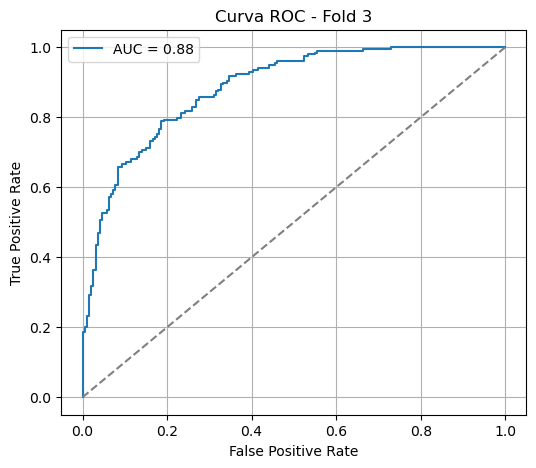


=== Fold 4/5 ===
Epoch 1/20
49/49 [==============================] - 35s 605ms/step - loss: 0.6279 - accuracy: 0.6765
Epoch 2/20
49/49 [==============================] - 29s 587ms/step - loss: 0.4594 - accuracy: 0.7781
Epoch 3/20
49/49 [==============================] - 28s 575ms/step - loss: 0.4334 - accuracy: 0.7948
Epoch 4/20
49/49 [==============================] - 27s 553ms/step - loss: 0.4276 - accuracy: 0.7877
Epoch 5/20
49/49 [==============================] - 26s 536ms/step - loss: 0.4235 - accuracy: 0.7960
Epoch 6/20
49/49 [==============================] - 29s 600ms/step - loss: 0.3941 - accuracy: 0.8088
Epoch 7/20
49/49 [==============================] - 29s 581ms/step - loss: 0.3912 - accuracy: 0.8171
Epoch 8/20
49/49 [==============================] - 28s 577ms/step - loss: 0.3934 - accuracy: 0.8191
Epoch 9/20
49/49 [==============================] - 28s 564ms/step - loss: 0.3861 - accuracy: 0.8095
Epoch 10/20
49/49 [==============================] - 27s 556ms/step - los

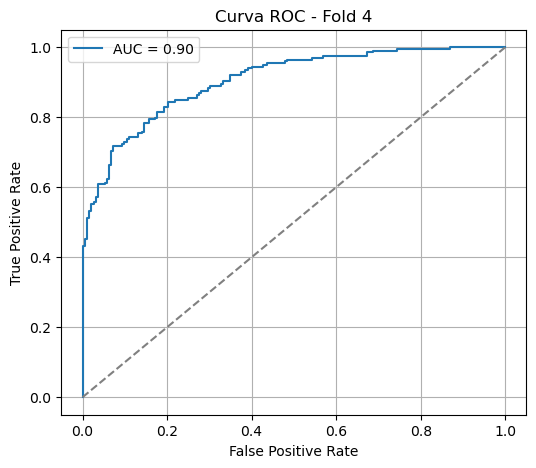


=== Fold 5/5 ===
Epoch 1/20
49/49 [==============================] - 34s 582ms/step - loss: 0.5623 - accuracy: 0.7148
Epoch 2/20
49/49 [==============================] - 27s 550ms/step - loss: 0.4817 - accuracy: 0.7609
Epoch 3/20
49/49 [==============================] - 29s 587ms/step - loss: 0.4459 - accuracy: 0.7769
Epoch 4/20
49/49 [==============================] - 28s 570ms/step - loss: 0.4362 - accuracy: 0.7832
Epoch 5/20
49/49 [==============================] - 27s 548ms/step - loss: 0.4135 - accuracy: 0.8012
Epoch 6/20
49/49 [==============================] - 27s 559ms/step - loss: 0.4102 - accuracy: 0.8024
Epoch 7/20
49/49 [==============================] - 29s 598ms/step - loss: 0.4015 - accuracy: 0.8075
Epoch 8/20
49/49 [==============================] - 27s 561ms/step - loss: 0.3927 - accuracy: 0.8043
Epoch 9/20
49/49 [==============================] - 28s 574ms/step - loss: 0.4049 - accuracy: 0.7999
Epoch 10/20
49/49 [==============================] - 28s 576ms/step - los

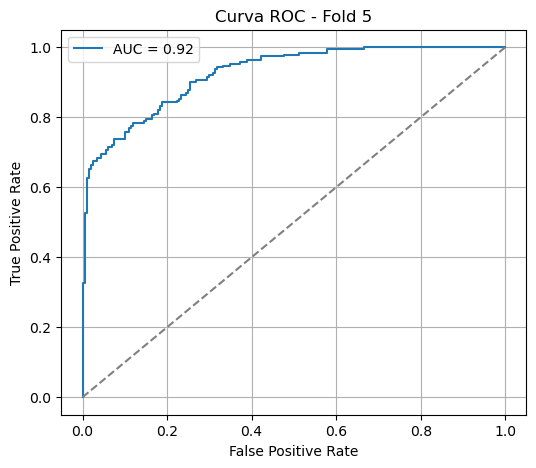

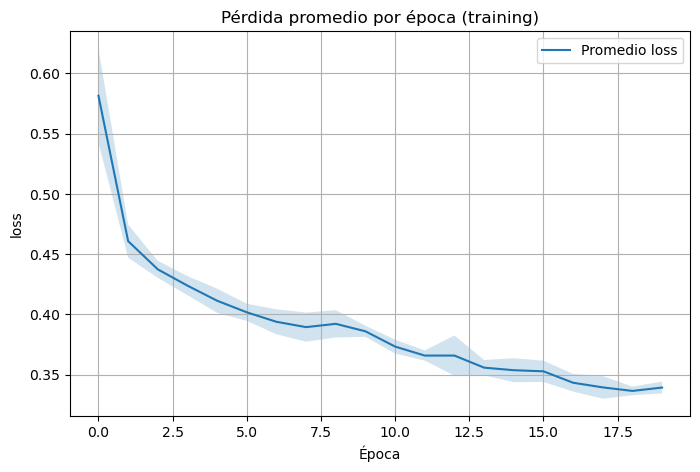

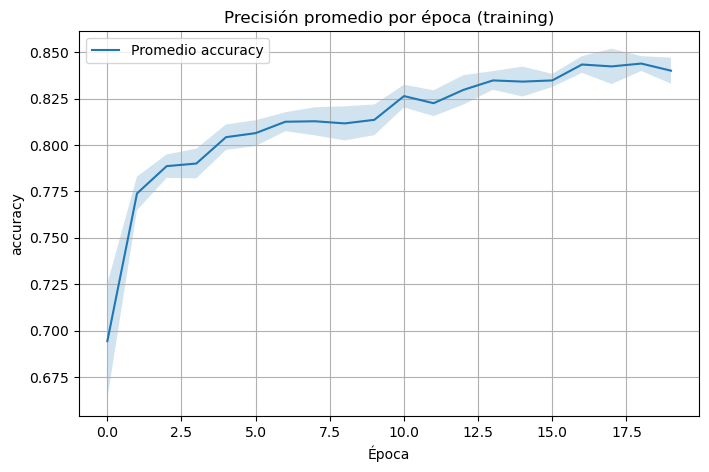


📊 Resultados Cross-Validation:
Fold 1: 0.7647
Fold 2: 0.8159
Fold 3: 0.7852
Fold 4: 0.8107
Fold 5: 0.8082

🔁 Promedio: 0.7969 ± 0.0192


In [ ]:
import os
import cv2
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, GlobalAveragePooling2D, Concatenate, Dropout
from tensorflow.keras.applications import MobileNetV2
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score

# ==== CARGA DE DATOS ====
e1 = pd.read_excel("datos_procesados_empresa1_con_imagen.xlsx")

# ==== CONFIGURACIÓN ====
img_base_dir = r"C:\Users\jupap\OneDrive - Universidad de los andes\Tesis Camiii\ProyectoGradoGEB\imagenes_diarias"
img_size = (224, 224)
batch_size = 32
epochs = 20
k_folds = 5

# ==== VARIABLES DE TIEMPO ====
features = ["STD_VOLUME", "ORIG_STD_VOLUME", "ORIG_TEMPERATURE", "TEMPERATURE",
            "PRESSURE", "ORIG_PRESSURE", "RAW_VOLUME", "ORIG_RAW_VOLUME"]
scaler = StandardScaler()
e1[features] = scaler.fit_transform(e1[features])

# ==== PREPARACIÓN DE DATOS ====
X_img, X_seq, y = [], [], []

for name, group in e1.groupby("image_filename"):
    img_path_normal = os.path.join(img_base_dir, "normal", name)
    img_path_anomalo = os.path.join(img_base_dir, "anomalo", name)

    if os.path.exists(img_path_anomalo):
        img_path = img_path_anomalo
        label = 1
    elif os.path.exists(img_path_normal):
        img_path = img_path_normal
        label = 0
    else:
        continue

    with open(img_path, 'rb') as f:
        file_bytes = np.asarray(bytearray(f.read()), dtype=np.uint8)
        img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

    if img is None:
        continue
    img = cv2.resize(img, img_size)
    img = img / 255.0

    seq = group[features].values
    if seq.shape[0] < 6:
        continue

    X_img.append(img)
    X_seq.append(seq)
    y.append(label)

if len(X_img) == 0:
    raise ValueError("No se cargaron datos.")

# ==== CONVERTIR A NUMPY ====
X_img = np.array(X_img)
X_seq = tf.keras.preprocessing.sequence.pad_sequences(X_seq, padding="post", dtype="float32")
y = np.array(y)

# ==== CROSS VALIDATION ====
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
all_scores = []

histories = []  # Guardar histories por fold


for fold, (train_idx, val_idx) in enumerate(kf.split(X_img)):
    print(f"\n=== Fold {fold+1}/{k_folds} ===")

    # División
    X_train_img, X_val_img = X_img[train_idx], X_img[val_idx]
    X_train_seq, X_val_seq = X_seq[train_idx], X_seq[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # Modelo CNN + LSTM
    img_input = Input(shape=(224, 224, 3))
    cnn_base = MobileNetV2(include_top=False, weights="imagenet", input_tensor=img_input)
    cnn_base.trainable = False
    cnn_output = GlobalAveragePooling2D()(cnn_base.output)

    seq_input = Input(shape=(X_seq.shape[1], X_seq.shape[2]))
    lstm_output = LSTM(64)(seq_input)

    fusion = Concatenate()([cnn_output, lstm_output])
    x = Dense(128, activation="relu")(fusion)
    x = Dropout(0.3)(x)
    output = Dense(1, activation="sigmoid")(x)

    model = Model(inputs=[img_input, seq_input], outputs=output)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

    # Entrenar modelo
    history = model.fit(
        [X_train_img, X_train_seq], y_train,
    validation_data=([X_val_img, X_val_seq], y_val),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
    )



    # Evaluación
    y_val_proba = model.predict([X_val_img, X_val_seq])
    y_val_pred = (y_val_proba > 0.5).astype(int)

    acc = accuracy_score(y_val, y_val_pred)
    all_scores.append(acc)
    print(f"✅ Accuracy del Fold {fold+1}: {acc:.4f}")

    # Matriz de confusión y ROC
    cm = confusion_matrix(y_val, y_val_pred)
    print("Matriz de Confusión:")
    print(cm)
    print("\nReporte de Clasificación:")
    print(classification_report(y_val, y_val_pred))

    fpr, tpr, _ = roc_curve(y_val, y_val_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.title(f"Curva ROC - Fold {fold+1}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid()
    plt.show()

    # Limpiar memoria entre folds
    tf.keras.backend.clear_session()
    gc.collect()
# === GRAFICAR PROMEDIO DE LOSS Y ACCURACY POR ÉPOCA ===
def plot_avg_metric(histories, metric_name, title):
    max_epochs = min(len(h[metric_name]) for h in histories)
    values = np.array([h[metric_name][:max_epochs] for h in histories])
    mean = values.mean(axis=0)
    std = values.std(axis=0)

    plt.figure(figsize=(8, 5))
    plt.plot(mean, label=f"Promedio {metric_name}")
    plt.fill_between(range(max_epochs), mean - std, mean + std, alpha=0.2)
    plt.title(title)
    plt.xlabel("Época")
    plt.ylabel(metric_name)
    plt.legend()
    plt.grid()
    plt.show()

# Gráficas de entrenamiento promedio
plot_avg_metric(histories, "loss", "Pérdida promedio por época (training)")
plot_avg_metric(histories, "accuracy", "Precisión promedio por época (training)")

# ==== RESULTADOS GENERALES ====
print("\n📊 Resultados Cross-Validation:")
for i, acc in enumerate(all_scores):
    print(f"Fold {i+1}: {acc:.4f}")
print(f"\n🔁 Promedio: {np.mean(all_scores):.4f} ± {np.std(all_scores):.4f}")


In [13]:
# === GRAFICAR PROMEDIO DE LOSS Y ACCURACY ===
def plot_avg_metric(histories, metric_name, title):
    max_epochs = min([len(h[metric_name]) for h in histories])
    metric_values = np.array([h[metric_name][:max_epochs] for h in histories])
    mean = metric_values.mean(axis=0)
    std = metric_values.std(axis=0)

    plt.figure(figsize=(8, 5))
    plt.plot(mean, label=f"Promedio {metric_name}")
    plt.fill_between(range(max_epochs), mean - std, mean + std, alpha=0.2)
    plt.title(title)
    plt.xlabel("Época")
    plt.ylabel(metric_name)
    plt.legend()
    plt.grid()
    plt.show()

# Gráficas
plot_avg_metric(histories, "loss", "Pérdida promedio por época")
plot_avg_metric(histories, "accuracy", "Precisión promedio por época")


NameError: name 'histories' is not defined